In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, random_split,Subset
from torchvision.datasets import ImageFolder
from sklearn.metrics import  confusion_matrix
from torch.utils.data.sampler import WeightedRandomSampler
import copy
import random

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\scipy\__init__.py:169: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
import sys

# 添加自定义模块的目录到模块搜索路径
sys.path.append(r'C:\Users\MJ\Desktop')

# 现在可以导入你的自定义模块
from MJPytorch import *

In [3]:
DATA_DIR = r'D:/indoor/Images'
model_algo="alexnet"

In [4]:

transform=transforms.Compose([
    transforms.Resize((229,229)),    
    transforms.ToTensor() 
])

In [5]:
#讀取資料且切分資料為train、valid、test

images=ImageDataset(DATA_DIR,transform,decision_mode=False)

generator = torch.Generator()
generator.manual_seed(124)

size = len(images)
valid_size = int(0.2 * size)

train_size = int(size - valid_size )

trainset, validset= random_split(images, (train_size, valid_size), generator=generator)


In [6]:
# create data loaders
batch_size =32 # larger numbers lead to CUDA running out of memory
train_dl = DataLoader(trainset,shuffle=True, batch_size=batch_size)
valid_dl = DataLoader(validset,shuffle=True, batch_size=batch_size)
criterion = nn.CrossEntropyLoss()

In [7]:
model_0=model_train(model_algo,train_dl,valid_dl,"0",70)
# model_0 = torch.load(f'model_{model_algo}_0_4.pth')

In [8]:
train_loss,train_accu,confusion_matrix_train=evaluate_model(model_0,train_dl,train_size,'0',mode='eval')
train_loss,train_accu

(0.09991584027069174, 0.9779929577464789)

In [9]:
valid_loss,valid_accu,confusion_matrix_valid=evaluate_model(model_0,valid_dl,valid_size,'0',mode='eval')
valid_loss,valid_accu

(1.548043994989041, 0.6117157490396927)

In [10]:
each_accu=np.diag(confusion_matrix_train)/confusion_matrix_train.sum(1)
each_accu

airport_inside    0.969325
artstudio         0.929825
auditorium        0.992701
bakery            0.978462
bar               0.961456
                    ...   
tv_studio         0.992063
videostore        0.918605
waitingroom       0.975207
warehouse         1.000000
winecellar        0.990476
Length: 67, dtype: float64

In [11]:
# sorted_accu = each_accu.sort_values()

In [12]:
# sorted_accu.iloc[-10:].index.map(trainset.dataset.classess)

In [13]:
# l=list(sorted_accu.iloc[:15].index.map(trainset.dataset.classess))
# l

In [14]:
# ll=list(sorted_accu.iloc[-15:].index.map(trainset.dataset.classess))
# ll

In [15]:
# targetF=[x  for x in (l+ll)]
# targetF

In [16]:
targetF=[x  for x in each_accu.nsmallest(35).index.map(trainset.dataset.classess)]
targetF

[40,
 29,
 63,
 46,
 1,
 61,
 20,
 33,
 41,
 32,
 47,
 38,
 4,
 27,
 55,
 30,
 0,
 48,
 64,
 57,
 60,
 53,
 37,
 22,
 17,
 35,
 52,
 3,
 24,
 56,
 12,
 5,
 39,
 34,
 58]

In [17]:
#將資料切分後建立dataset與dataloader
indexF=[]
indexT=[]
split_mode=('classaccu',targetF)
indexF,indexT=split_data(model_0,train_dl,split_mode)

Fdataset=Subset(images, indexF)
Tdataset=Subset(images, indexT)
Fdl=DataLoader(Fdataset, shuffle=True, batch_size=batch_size)
Tdl=DataLoader(Tdataset, shuffle=True, batch_size=batch_size)
len(indexF),len(indexT)

(6584, 5912)

In [18]:
indexF_v=[]
indexT_v=[]

indexF_v,indexT_v=split_data(model_0,valid_dl,split_mode)
len(indexF_v),len(indexT_v)

(1635, 1489)

In [19]:
Fdataset_v=Subset(images, indexF_v)
Tdataset_v=Subset(images, indexT_v)
Fdl_v=DataLoader(Fdataset_v, shuffle=True, batch_size=batch_size)
Tdl_v=DataLoader(Tdataset_v, shuffle=True, batch_size=batch_size)

In [20]:
d_data,d_target=decision_split(train_dl,model_0)
d_v_data,d_v_target=decision_split(valid_dl,model_0)

In [21]:
decisionset=DecisionDataset(d_data,d_target)
decisionset_v=DecisionDataset(d_v_data,d_v_target)

c:\Users\MJ\anaconda3\envs\MJ\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch=0,train_loss=0.626465746214692,train_accu=0.6454065300896287
Epoch=0,valid_loss=0.6396457682651076,valid_accu=0.6251600512163893
0
Epoch=1,train_loss=0.5346477076735601,train_accu=0.7407970550576184
Epoch=1,valid_loss=0.6004329518380452,valid_accu=0.6600512163892446
0
Epoch=2,train_loss=0.4161305461512943,train_accu=0.8068982074263764
Epoch=2,valid_loss=0.5956572511742576,valid_accu=0.6949423815620999
0
Epoch=3,train_loss=0.4546217758890609,train_accu=0.7948143405889885
Epoch=3,valid_loss=0.7740063868777852,valid_accu=0.6686939820742638
Epoch=4,train_loss=0.38009650575977283,train_accu=0.8241037131882202
Epoch=4,valid_loss=0.7731948749051356,valid_accu=0.6574903969270166
Epoch=5,train_loss=0.23750454852316963,train_accu=0.9034090909090909
Epoch=5,valid_loss=0.6937962037042528,valid_accu=0.6949423815620999
Epoch=6,train_loss=0.2099822810666204,train_accu=0.9094910371318822
Epoch=6,valid_loss=0.8522633805622976,valid_accu=0.6987836107554417
0
Epoch=7,train_loss=0.14787308015072392,

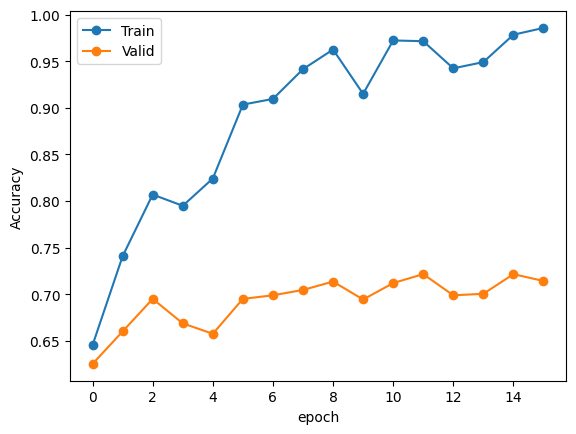

In [22]:
from torchsampler import ImbalancedDatasetSampler
decision_dl = DataLoader(decisionset, batch_size=32)
decision_v_dl = DataLoader(decisionset_v, batch_size=32)
model_decision=model_train(model_algo,decision_dl,decision_v_dl,"decision",70,trainclassnum=len(trainset.dataset.classes))

Epoch=0,train_loss=0.7533560337168599,train_accu=0.7814614343707713
Epoch=0,valid_loss=1.092501620064653,valid_accu=0.6702484889187375
0
Epoch=1,train_loss=0.41419459173659995,train_accu=0.8956359945872802
Epoch=1,valid_loss=0.9319086435899548,valid_accu=0.7239758226997985
0
Epoch=2,train_loss=0.20671343458602168,train_accu=0.9485791610284168
Epoch=2,valid_loss=0.9053891251117612,valid_accu=0.7320349227669577
0
Epoch=3,train_loss=0.08550485952458621,train_accu=0.9798714479025711
Epoch=3,valid_loss=0.9423845414750283,valid_accu=0.7293485560779046
Epoch=4,train_loss=0.08200632519667139,train_accu=0.9790257104194858
Epoch=4,valid_loss=1.0127291626943047,valid_accu=0.722632639355272
Epoch=5,train_loss=0.04282334531847695,train_accu=0.9901894451962111
Epoch=5,valid_loss=1.0306939554342573,valid_accu=0.7421087978509067
0
Epoch=6,train_loss=0.024473687287934216,train_accu=0.996447902571042
Epoch=6,valid_loss=0.9846139841227022,valid_accu=0.7515110812625924
0
Epoch=7,train_loss=0.0229779686690

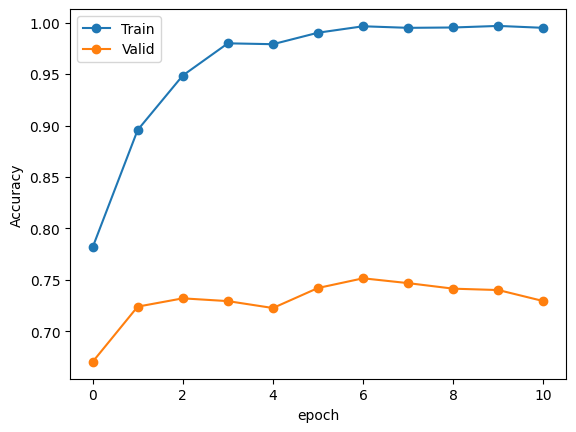

In [23]:
#訓練模型T、F、decision
model_T=model_train(model_algo,Tdl,Tdl_v,"T",70)
# model_T=torch.load(f'model_{model_algo}_T_5.pth')

Epoch=0,train_loss=1.094671709279678,train_accu=0.6701093560145808
Epoch=0,valid_loss=1.4485008630183858,valid_accu=0.5700305810397553
0
Epoch=1,train_loss=0.6343033758432288,train_accu=0.8236634264884569
Epoch=1,valid_loss=1.2474253330755671,valid_accu=0.6256880733944954
0
Epoch=2,train_loss=0.3589731557328675,train_accu=0.9100850546780073
Epoch=2,valid_loss=1.2179183191480258,valid_accu=0.6385321100917432
0
Epoch=3,train_loss=0.19333154865668437,train_accu=0.943955042527339
Epoch=3,valid_loss=1.3305872059834478,valid_accu=0.636085626911315
Epoch=4,train_loss=0.08721270226621107,train_accu=0.9767618469015796
Epoch=4,valid_loss=1.4156071527288594,valid_accu=0.6434250764525994
0
Epoch=5,train_loss=0.05589213606563113,train_accu=0.9866342648845686
Epoch=5,valid_loss=1.363218954652092,valid_accu=0.6648318042813456
0
Epoch=6,train_loss=0.0548242700997998,train_accu=0.9881530984204131
Epoch=6,valid_loss=1.4782176638232822,valid_accu=0.6617737003058104
Epoch=7,train_loss=0.06115120493966457,

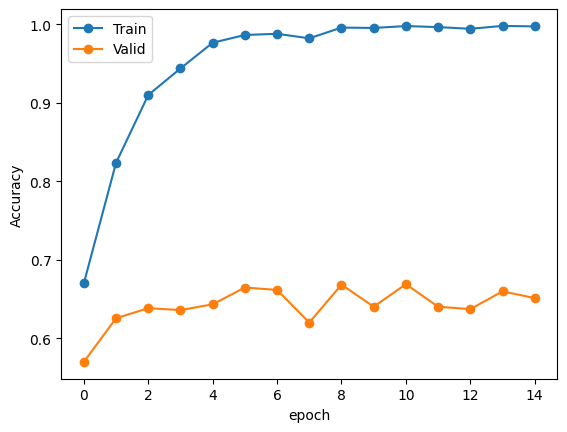

In [24]:
model_F=model_train(model_algo,Fdl,Fdl_v,"F",70)
# model_F=torch.load(f'model_{model_algo}_F_6.pth')

In [25]:
decision_loss,decision_accu,confusion_matrix_decision_train=evaluate_model(model_decision,decision_dl,len(decisionset),'decision',mode='eval')
confusion_matrix_decision_train= confusion_matrix_decision_train.rename(columns={"0":"False","1":"True"}, index={"0":"False","1":"True"})
decision_loss,decision_accu

(0.07926885201327417, 0.9714308578745199)

In [26]:
decision_valid_loss,decision_valid_accu,confusion_matrix_decision_valid=evaluate_model(model_decision,decision_v_dl,len(decisionset_v),'decision',mode='eval')
confusion_matrix_decision_valid= confusion_matrix_decision_valid.rename(columns={0:"False",1:"True"}, index={0:"False",1:"True"})
decision_valid_loss,decision_valid_accu

(1.1330662530759843, 0.7215108834827144)

In [27]:
T_loss,T_accu,confusion_matrix_T_train=evaluate_model(model_T,Tdl,len(Tdataset),'T',mode='eval')
T_loss,T_accu

(0.024473687966577257, 0.996447902571042)

In [28]:
F_loss,F_accu,confusion_matrix_F_train=evaluate_model(model_F,Fdl,len(Fdataset),'F',mode='eval')
F_loss,F_accu

(0.011926824750349306, 0.9980255164034022)

In [29]:
T_valid_loss,T_valid_accu,confusion_matrix_T_valid=evaluate_model(model_T,Tdl_v,len(Tdataset_v),'T',mode='eval')
T_valid_loss,T_valid_accu

(0.9846139913280991, 0.7515110812625924)

In [30]:
F_valid_loss,F_valid_accu,confusion_matrix_F_valid=evaluate_model(model_F,Fdl_v,len(Fdataset_v),'F',mode='eval')
F_valid_loss,F_valid_accu

(1.533878414054894, 0.6691131498470948)

In [31]:
total_train_loss_d,total_train_accu_d,confusion_matrix_total_train,sum_all=total_model_evaluate_notdecision(train_dl,train_size,model_0,model_T,model_F)
total_train_loss_d,total_train_accu_d,sum_all

(0.01786218805682205, 0.9972791293213829, 6584)

In [32]:
total_valid_loss_d,total_valid_accu_d,confusion_matrix_total_valid_d,sum_all=total_model_evaluate_notdecision(valid_dl,valid_size,model_0,model_T,model_F)
total_valid_loss_d,total_valid_accu_d,sum_all

(1.2720825382139862, 0.7083866837387964, 1635)

In [33]:
total_train_loss,total_train_accu,confusion_matrix_total_train,sum_F,sum_T=total_model_evaluate(train_dl,train_size,model_0,model_T,model_F,model_decision)
total_train_loss,total_train_accu,sum_F,sum_T

(0.5398532750312163, 0.9687099871959027, 6759, 5737)

In [34]:
total_valid_loss,total_valid_accu,confusion_matrix_total_valid,sum_F,sum_T=total_model_evaluate(valid_dl,valid_size,model_0,model_T,model_F,model_decision)
total_valid_loss,total_valid_accu,sum_F,sum_T

(5.858559780023162, 0.5406530089628682, 1815, 1309)

In [35]:
train_losses=[train_loss,decision_loss,T_loss,F_loss,total_train_loss,total_train_loss_d]
train_accuracies=[train_accu,decision_accu,T_accu,F_accu,total_train_accu,total_train_accu_d]
valid_losses=[valid_loss,decision_loss,T_valid_loss,F_valid_loss,total_valid_loss,total_valid_loss_d]
valid_accuracies=[valid_accu,decision_valid_accu,T_valid_accu,F_valid_accu,total_valid_accu,total_valid_accu_d]

In [36]:
model_algos=['Model_0','Model_Decision',"Model_T","Model_F","Total_Model",'Total_Model_without_decision']
data = {
    'Model': model_algos,
    'Train Loss': train_losses,
    'Train Accuracy': train_accuracies,
    'Valid Loss': valid_losses,
    'Valid Accuracy': valid_accuracies
}
df = pd.DataFrame(data)
df

,Model,Train Loss,Train Accuracy,Valid Loss,Valid Accuracy
0,Model_0,0.099916,0.977993,1.548044,0.611716
1,Model_Decision,0.079269,0.971431,0.079269,0.721511
2,Model_T,0.024474,0.996448,0.984614,0.751511
3,Model_F,0.011927,0.998026,1.533878,0.669113
4,Total_Model,0.539853,0.968710,5.858560,0.540653
5,Total_Model_without_decision,0.017862,0.997279,1.272083,0.708387


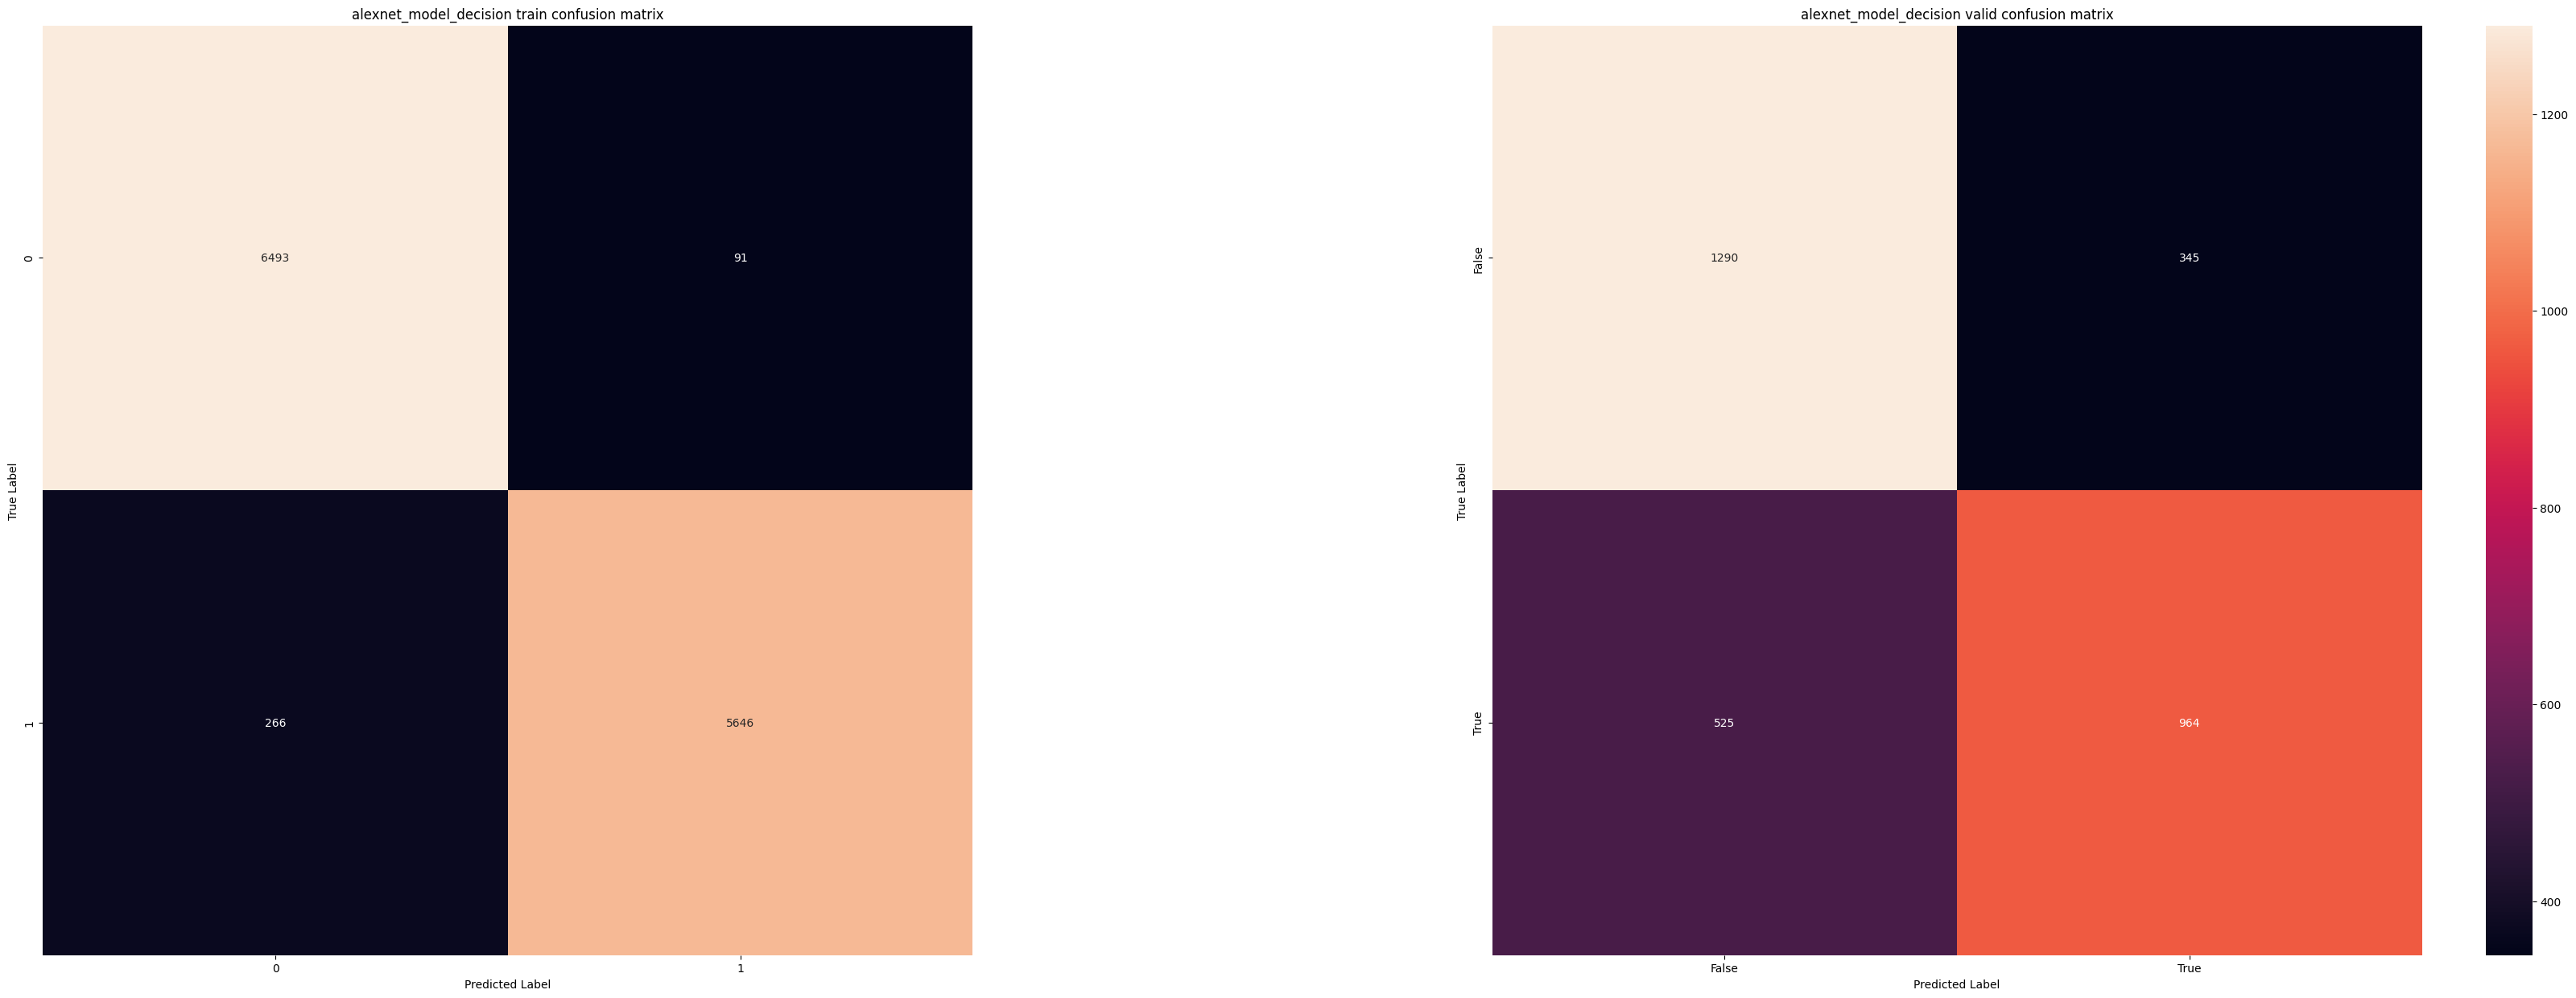

In [37]:
plot_confusion_matrix(confusion_matrix_decision_train,confusion_matrix_decision_valid,"model_decision",model_algo)

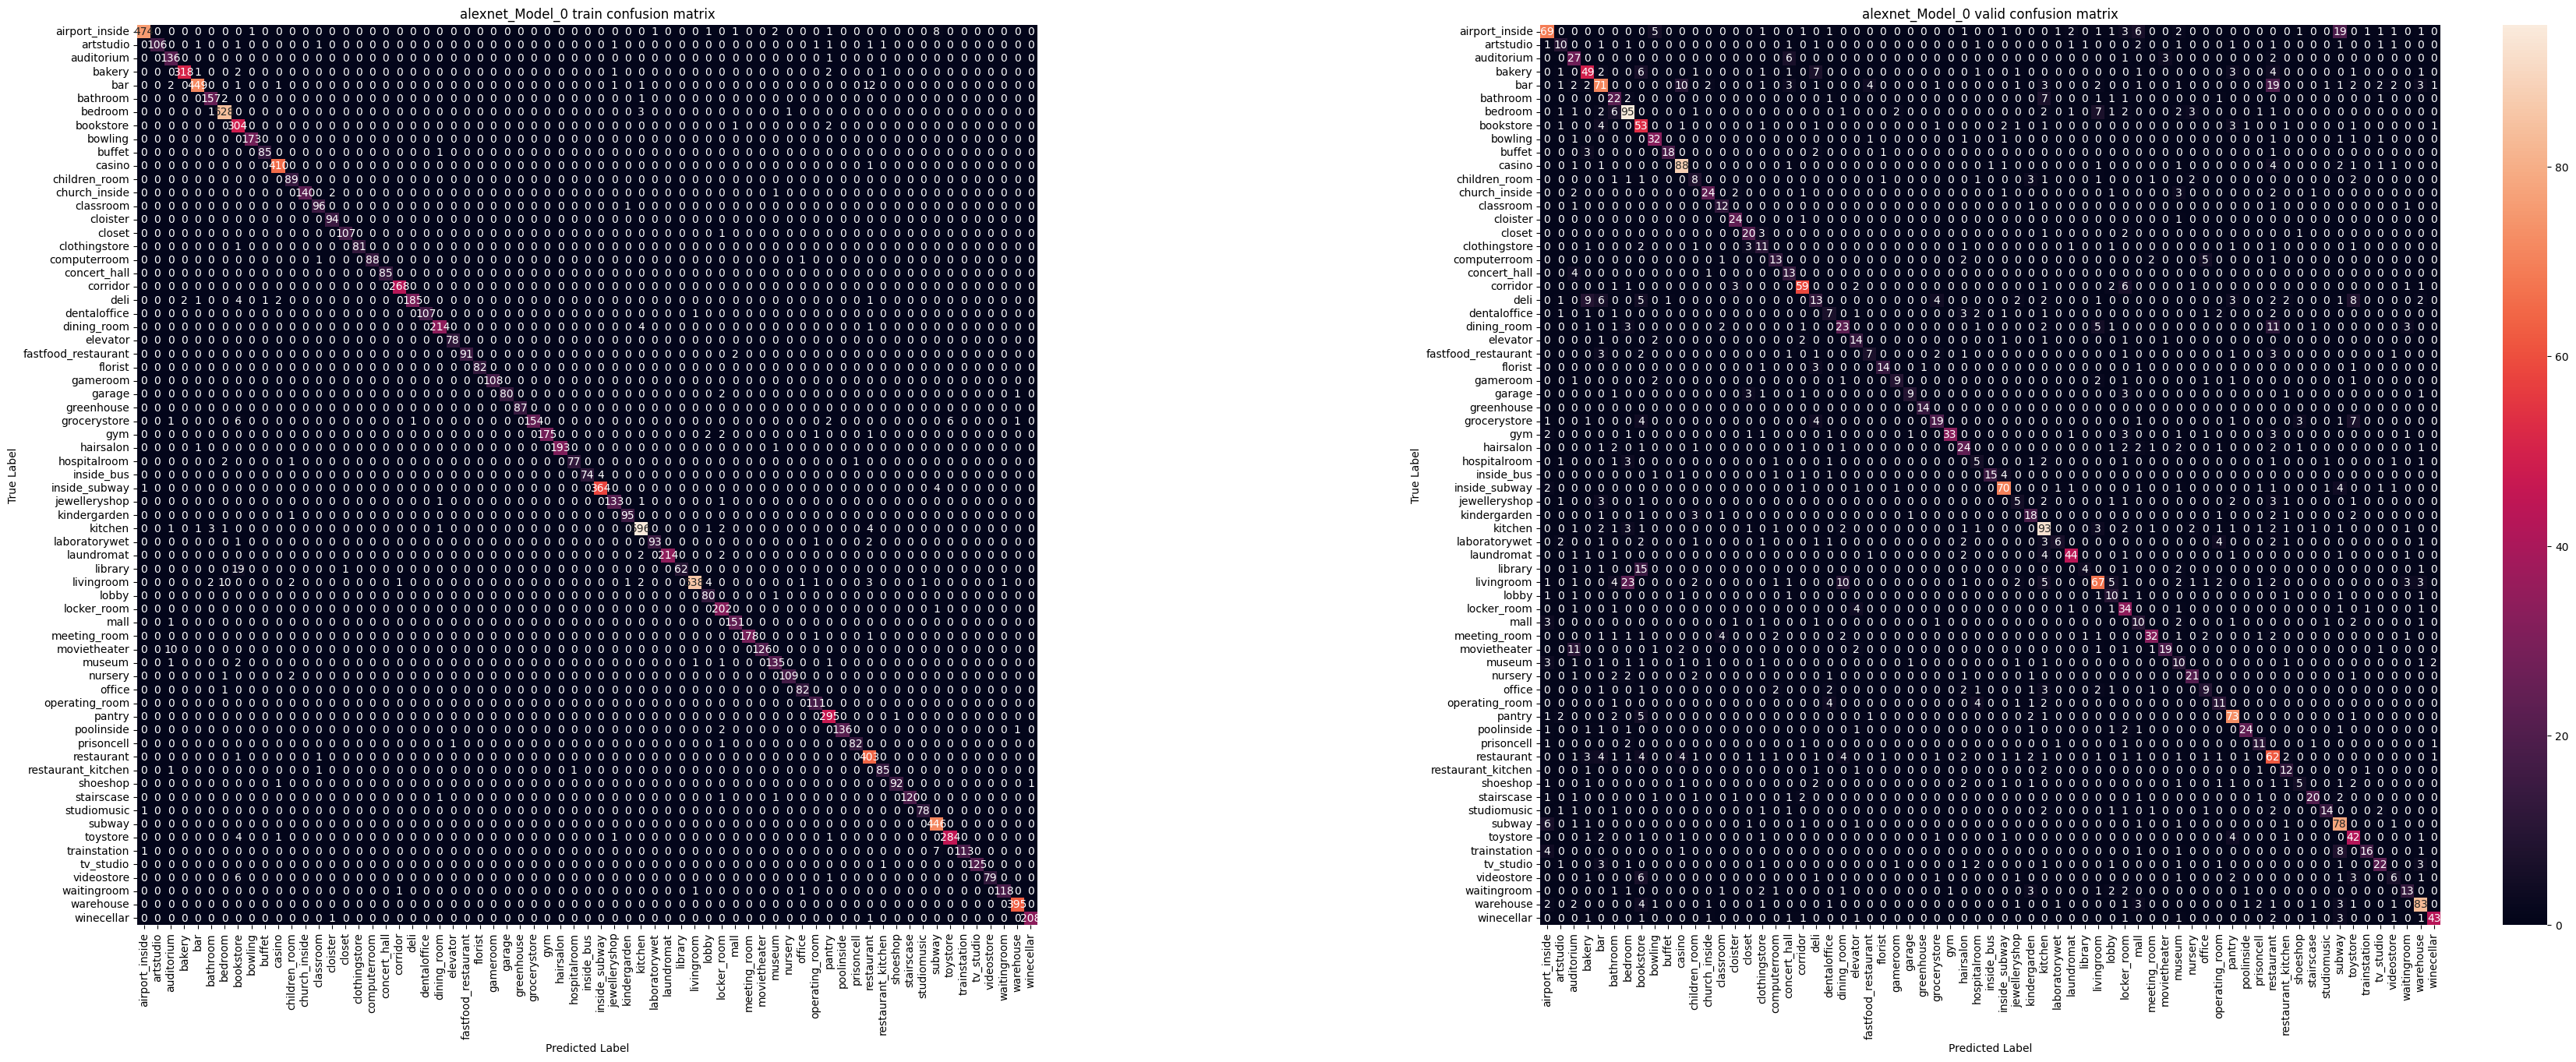

In [38]:
plot_confusion_matrix(confusion_matrix_train,confusion_matrix_valid,"Model_0",model_algo)

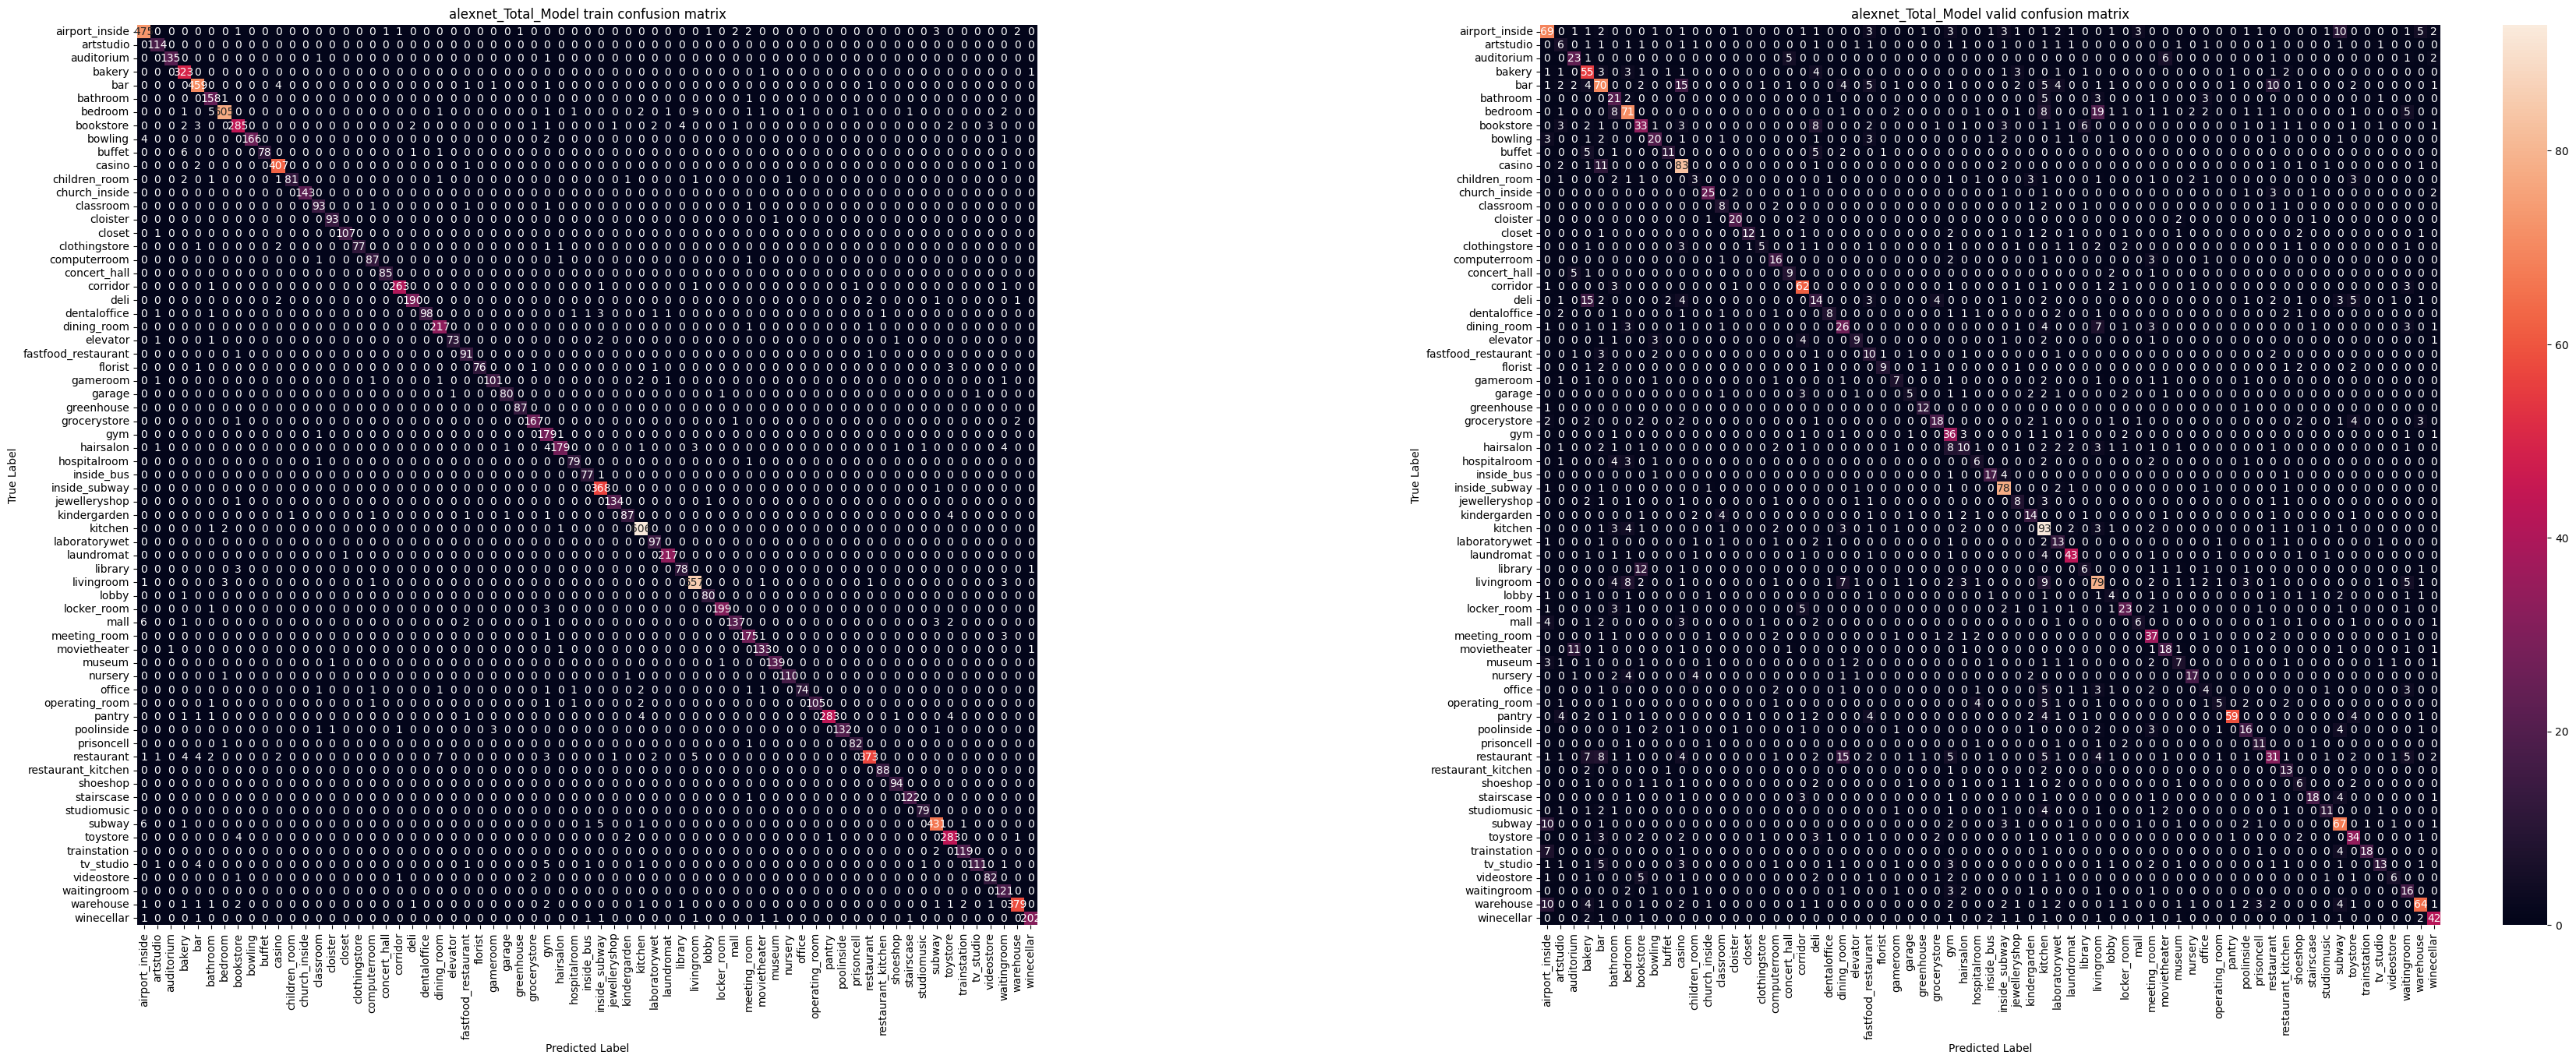

In [39]:
plot_confusion_matrix(confusion_matrix_total_train,confusion_matrix_total_valid,"Total_Model",model_algo)

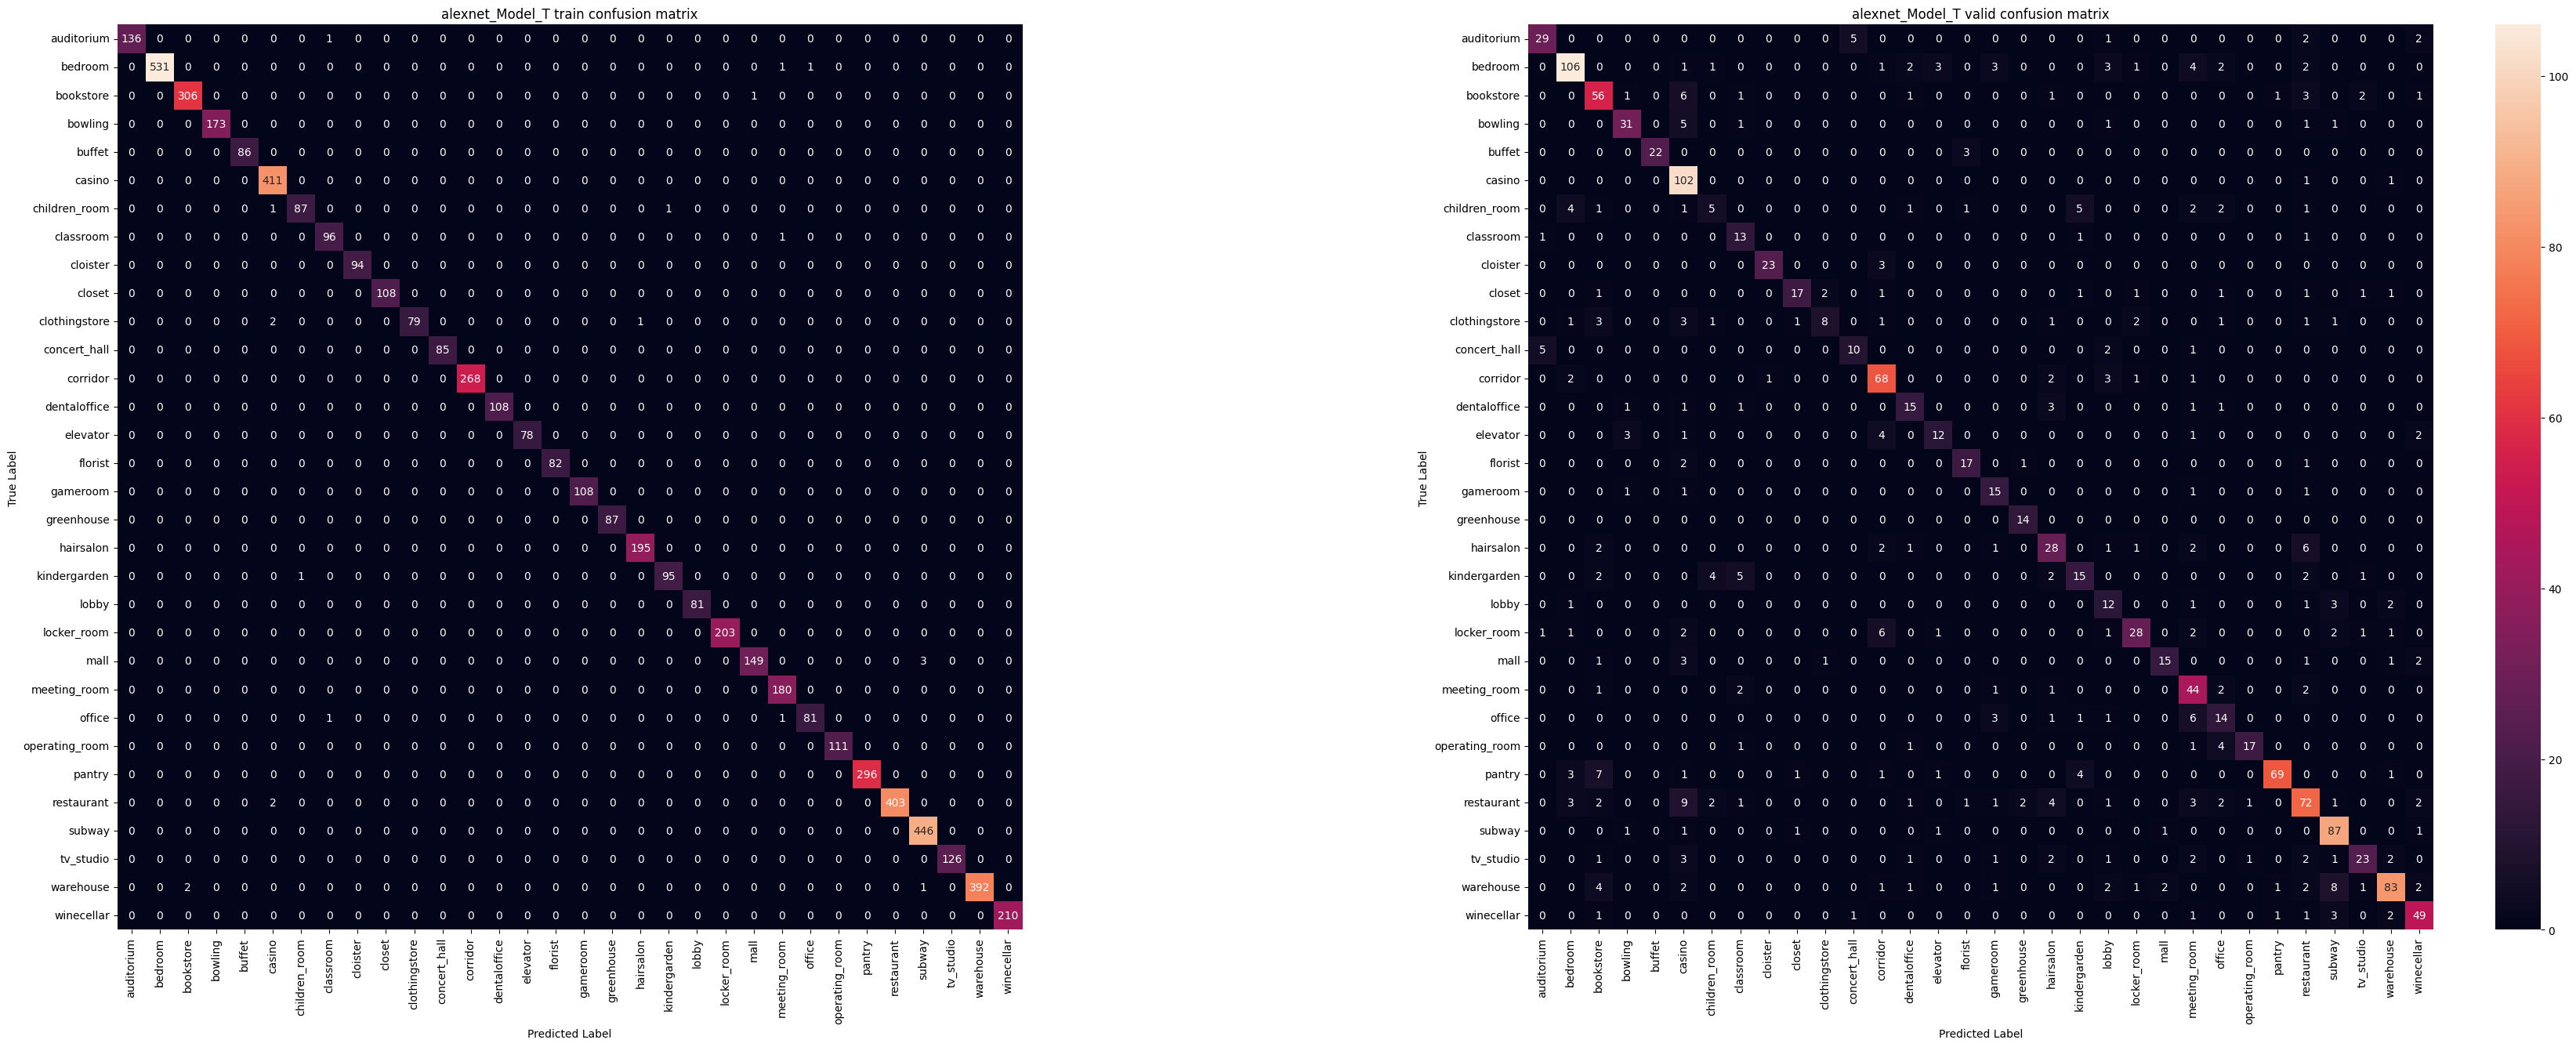

In [40]:
plot_confusion_matrix(confusion_matrix_T_train,confusion_matrix_T_valid,"Model_T",model_algo)

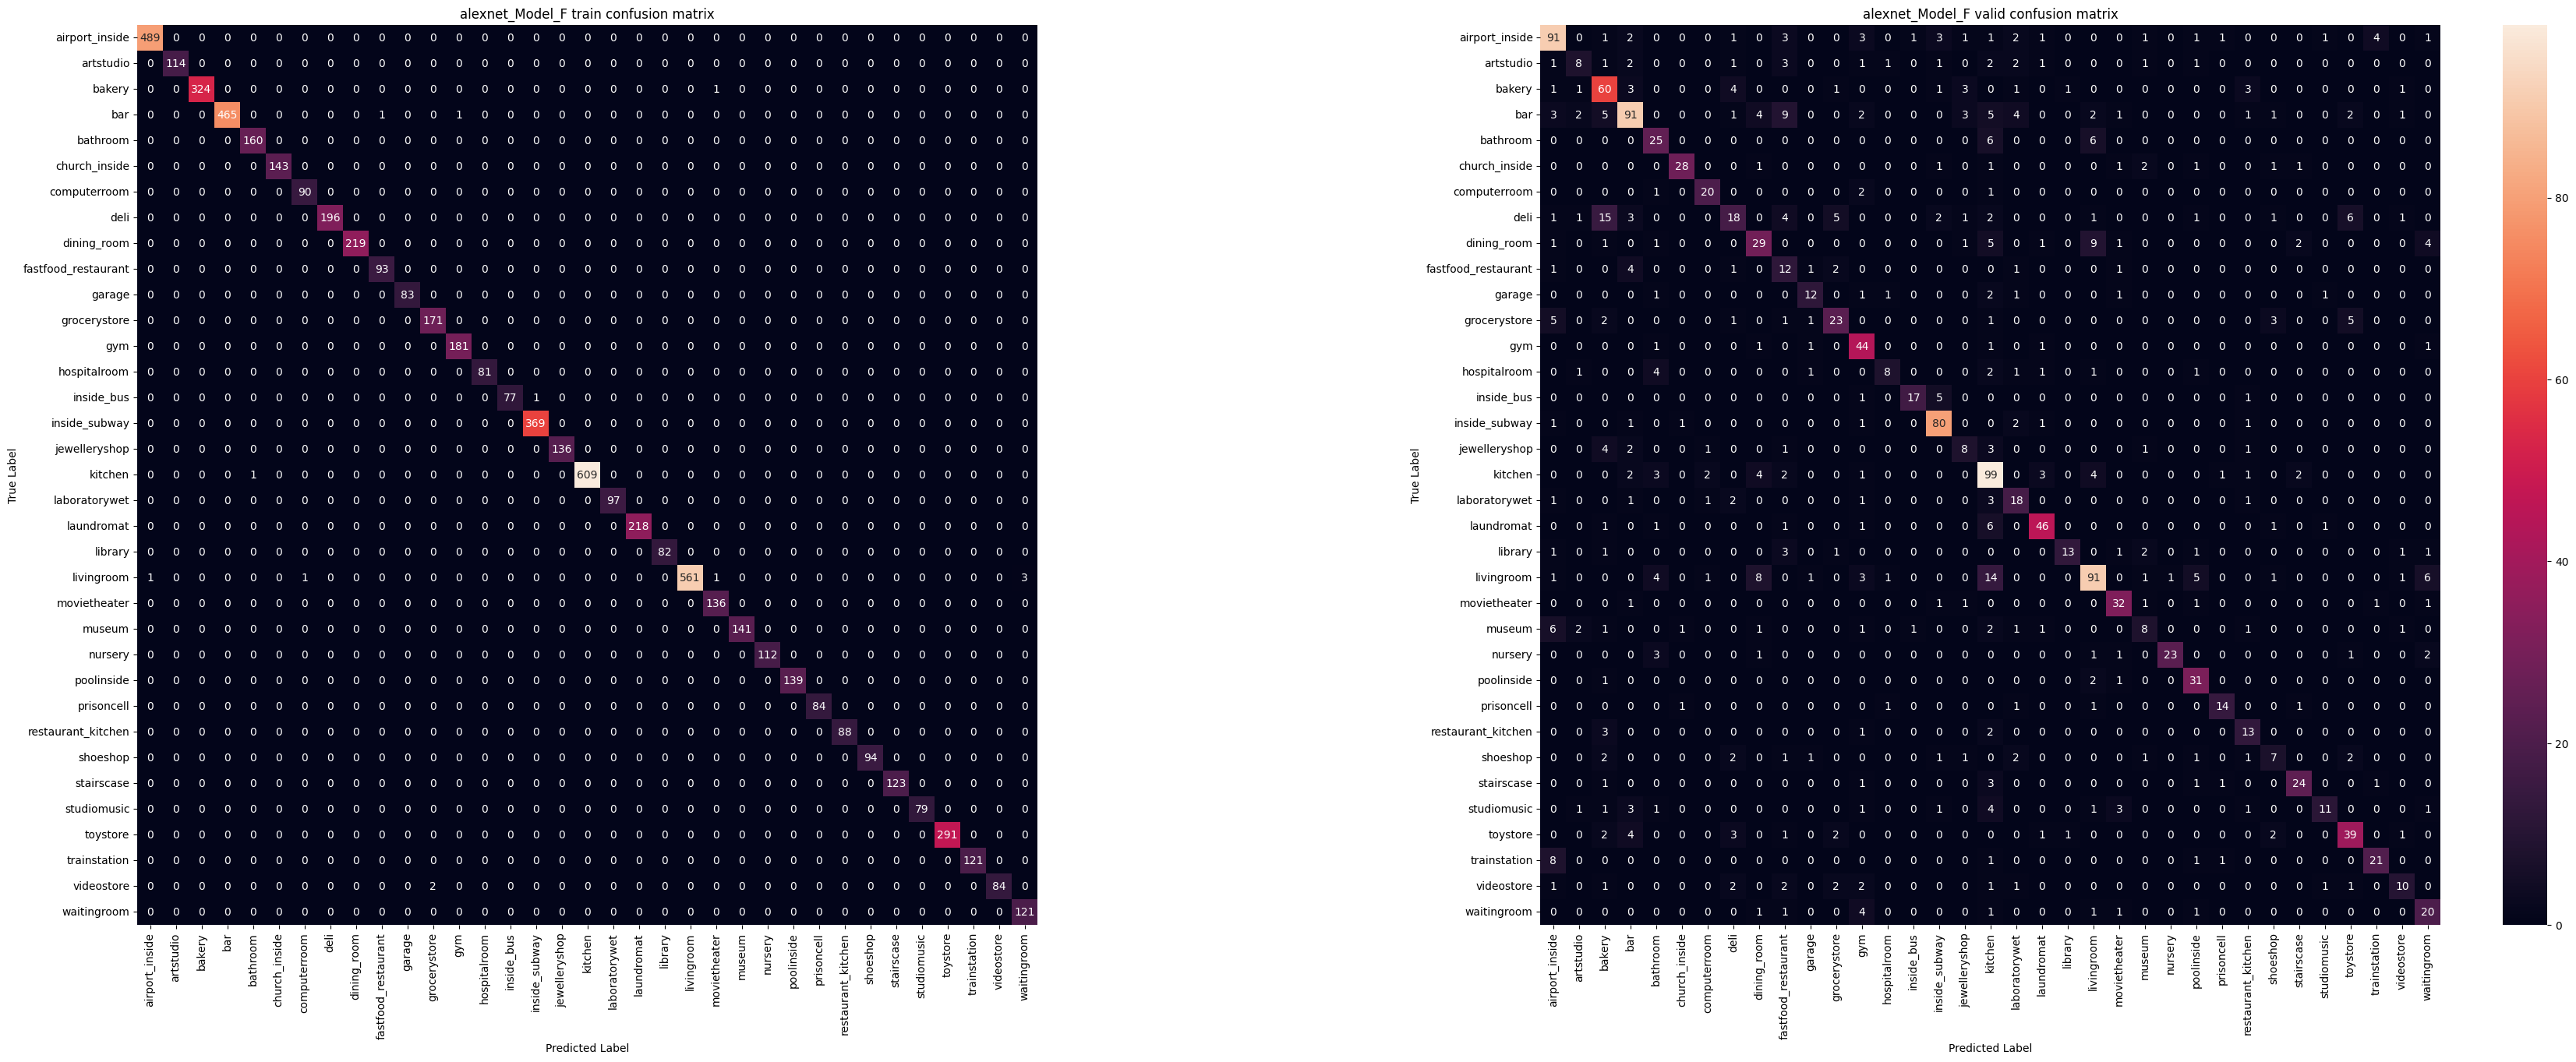

In [41]:
plot_confusion_matrix(confusion_matrix_F_train,confusion_matrix_F_valid,"Model_F",model_algo)

In [42]:
# model_T_embed=copy.copy(model_T)
# model_T_embed.classifier[5]=nn.Identity()
# model_T_embed.classifier[6]=nn.Identity()
# model_F_embed=copy.copy(model_F)
# model_F_embed.classifier[5]=nn.Identity()
# model_F_embed.classifier[6]=nn.Identity()

In [43]:
model_0

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [44]:
model_0_embed= copy.deepcopy(model_0)
# model_0_embed.classifier[5]=nn.Identity()
model_0_embed.classifier[6]=nn.Identity()

In [45]:
model_0_embed

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [53]:
ALL=set(range(67))
targetT=list(ALL-set(targetF))

In [55]:
mean_features_dict_T = {class_idx: [] for class_idx in targetT}
for data, target, idx in Tdl:
    with torch.no_grad():
        data, target = data.to(device), target.to(device)
        out=model_0_embed(data)
        for feature, class_idx in zip(out, target):
            if class_idx not in  targetF:
                mean_features_dict_T[class_idx.item()].append(feature.cpu().view(-1))

# 计算每个 targetF 类别的平均特征向量
mean_features_T = {}
for class_idx, features_list in mean_features_dict_T.items():
    mean_features_T[class_idx] = torch.mean(torch.stack(features_list), dim=0)


In [56]:
mean_features_dict_F = {class_idx: [] for class_idx in targetF}
for data, target, idx in Fdl:
    with torch.no_grad():
        data, target = data.to(device), target.to(device)
        out=model_0_embed(data)
        for feature, class_idx in zip(out, target):
            if class_idx in targetF:
                mean_features_dict_F[class_idx.item()].append(feature.cpu().view(-1))

# 计算每个 targetF 类别的平均特征向量
mean_features_F = {}
for class_idx, features_list in mean_features_dict_F.items():
    mean_features_F[class_idx] = torch.mean(torch.stack(features_list), dim=0)

In [109]:
mean_features_F

{40: tensor([4.2132, 0.0000, 1.8894,  ..., 0.9019, 0.0000, 0.4014]),
 29: tensor([3.4101, 0.0000, 0.5237,  ..., 0.0061, 0.0000, 0.0946]),
 63: tensor([4.5856, 0.0490, 2.5675,  ..., 0.1732, 0.0000, 0.2890]),
 46: tensor([3.3122, 0.0641, 0.1147,  ..., 0.0351, 0.0000, 0.0298]),
 1: tensor([1.5195, 0.0584, 0.1931,  ..., 0.2656, 0.0000, 0.3643]),
 61: tensor([0.2616, 0.0469, 1.1283,  ..., 0.0000, 0.0000, 2.1954]),
 20: tensor([0.7876, 0.0483, 0.3719,  ..., 0.1833, 0.0000, 0.1398]),
 33: tensor([3.6012, 0.0320, 0.3463,  ..., 0.0341, 0.0000, 2.4393]),
 41: tensor([0.8099, 0.0391, 0.3472,  ..., 0.0858, 0.0000, 0.2994]),
 32: tensor([1.2928, 0.3323, 0.0818,  ..., 0.0000, 0.0000, 0.6830]),
 47: tensor([1.3246, 0.0121, 1.1982,  ..., 0.0204, 0.0000, 0.5685]),
 38: tensor([2.1250, 0.0316, 1.3548,  ..., 0.0039, 0.0000, 1.4775]),
 4: tensor([0.1335, 0.0590, 0.4136,  ..., 0.7117, 0.0000, 0.2657]),
 27: tensor([1.6515, 0.0181, 1.0769,  ..., 0.0000, 0.0000, 0.6474]),
 55: tensor([0.1760, 0.3566, 0.2447,

In [59]:
import torch.nn.functional as F
def calculate_sim_max_idx(f,mean_features):
    k=0
    max=0
    for i in mean_features.keys():
        sim=F.cosine_similarity(f,mean_features[i], dim=0)
        if(max<sim):
            k=i
            max=sim
    return k,max

In [89]:
import torch.nn.functional as F
sum_all=0
sum_F=0
sum_T=0
with torch.no_grad():
    for data,target,idx in train_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
                else:
                    sum_F+=1
            else:
                if(t in targetF):
                    sum_all+=1
                else:
                    sum_T+=1

    sum_all=sum_all/train_size
sum_all,sum_F,sum_T

(0.9012483994878361, 695, 539)

In [104]:
import torch.nn.functional as F
sum_all=0
sum_F=0
sum_T=0
with torch.no_grad():
    for data,target,idx in valid_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
                else:
                    sum_F+=1
            else:
                if(t in targetF):
                    sum_all+=1
                else:
                    sum_T+=1

    sum_all=sum_all/valid_size
sum_all,sum_F,sum_T

(0.764404609475032, 412, 324)

In [ ]:
27  in targetF

True

In [ ]:
# tl=[]
# ff=[]
# for data,target,idx in train_dl:
#     data,target=data.to(device),target.to(device)
    
#     for t,d in zip(target,data):
#         if(t==28):
#             out=model_T(d.unsqueeze(0))
#             tl.append(out)
#             outf=model_F(d.unsqueeze(0))
#             ff.append(outf)

In [ ]:
len(mean_feature_F.values)

157323

In [ ]:
mean_features_F.keys()

dict_keys([40, 29, 63, 46, 1, 61, 20, 33, 41, 32, 47, 38, 4, 27, 55, 43, 51, 10, 18, 19, 59, 26, 25, 14, 28, 50, 11, 65, 23, 8])

In [ ]:
k_T,max_T=calculate_sim_max_idx(mean_features_T,f[6])

In [ ]:
k_F,max_F=calculate_sim_max_idx(mean_features_F,f[6])

In [ ]:
similarity = F.cosine_similarity(f[20],mean_features_F[40], dim=0)
similarity

tensor(0.7026)

In [ ]:
similarity = F.cosine_similarity(f[20],mean_features_T[7], dim=0)
similarity

tensor(0.5467)

In [110]:
import torch.nn.functional as F
sum_all=0
with torch.no_grad():
    for data,target,idx in train_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
            else:
                if(t in targetF):
                    sum_all+=1

    sum_all=sum_all/train_size
sum_all

0.9012483994878361

In [61]:
import torch.nn.functional as F
sum_all=0
with torch.no_grad():
    for data,target,idx in valid_dl:
 
        data,target=data.to(device),target.to(device)

        out = model_0_embed(data)
     
        for data,t in zip(out,target):
            # print(len(o))
            k_T,similarity_T = calculate_sim_max_idx(data.cpu().view(-1), mean_features_T)
            k_F,similarity_F = calculate_sim_max_idx(data.cpu().view(-1), mean_features_F)
 
            if(similarity_T>similarity_F):
                if(t not in targetF):
                    sum_all+=1
            else:
                if(t in targetF):
                    sum_all+=1

    sum_all=sum_all/valid_size
sum_all

0.764404609475032

In [64]:
#全部模型裝在一起的表現
def total_model_cos_evaluate(data_dl,size,model_0_embed,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_0_embed(data)
            # softmax_0=torch.softmax(out_growth, dim=1)
            # _, y_pred = torch.max(out_growth, dim = 1) 
            
            for d,out,t in zip(data,out,target):

                k_T,similarity_T = calculate_sim_max_idx(out.cpu().view(-1), mean_features_T)
                k_F,similarity_F = calculate_sim_max_idx(out.cpu().view(-1), mean_features_F)

                if(similarity_T>similarity_F):
                    out_T = model_T(d.unsqueeze(0))
                    outputs.append(out_T)
                    sum_T+=1
                else:
                    out_F = model_F(d.unsqueeze(0))
                    outputs.append(out_F)
                    sum_F+=1
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [65]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_cos_evaluate(train_dl,train_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(1.917381347342491, 0.8990076824583867, 6428, 6068)

In [66]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_cos_evaluate(valid_dl,valid_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(5.218194845543933, 0.5841869398207427, 1547, 1577)

In [68]:
def choose_with_model(data):
    out_decision=model_decision(data)
    _, pred = torch.max(out_decision, dim = 1) 
    softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
    if(pred==0):
        return 0
    else:
        return 1

In [69]:
def choose_with_softmax(data):
    out_T = model_T(data)
    softmax_T=torch.softmax(out_T, dim=1)

    out_F = model_F(data)
    softmax_F=torch.softmax(out_F, dim=1)

    st_max=torch.max(softmax_T).item()
    sf_max=torch.max(softmax_F).item()

    if(sf_max>st_max):
        return 0
    else:
        return 1

In [82]:
def choose_with_sim(out,mean_features_T,mean_features_F):
    k_T,similarity_T = calculate_sim_max_idx(out.cpu().view(-1), mean_features_T)
    k_F,similarity_F = calculate_sim_max_idx(out.cpu().view(-1), mean_features_F)
    if(similarity_T>similarity_F):
        return 1
    else:
        return 0


In [103]:
import torch.nn.functional as F
sum_all=0
sum_T=0
sum_F=0
list_T=[]
list_F=[]
with torch.no_grad():
    for data,target,idx in valid_dl:
        data,target=data.to(device),target.to(device)
        out = model_0_embed(data)
     
        for d,out,t in zip(data,out,target):
            sim_decision=choose_with_sim(out,mean_features_T,mean_features_F)
            soft_decision=choose_with_softmax(d.unsqueeze(0))
            mo_decision=choose_with_model(d.unsqueeze(0))
            total_decision=sim_decision+soft_decision+mo_decision

            if(total_decision>=2):
                if(t not in targetF):
                    sum_all+=1
                else:
                   sum_T+=1
                   list_F.append(t.item())
            else:
                if(t in targetF):
                    sum_all+=1
                else:
                   sum_F+=1
                   list_T.append(t.item())

    sum_all=sum_all/valid_size
sum_all,sum_T,sum_F

(0.7797695262483995, 338, 350)

In [85]:
#全部模型裝在一起的表現
def total_model_decision_evaluate(data_dl,size,model_0_embed,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out = model_0_embed(data)
            # softmax_0=torch.softmax(out_growth, dim=1)
            # _, y_pred = torch.max(out_growth, dim = 1) 
            
            for d,out,t in zip(data,out,target):

                sim_decision=choose_with_sim(out,mean_features_T,mean_features_F)
                soft_decision=choose_with_softmax(d.unsqueeze(0))
                mo_decision=choose_with_model(d.unsqueeze(0))
                total_decision=sim_decision+soft_decision+mo_decision

                if(total_decision>=2):
                    out_T = model_T(d.unsqueeze(0))
                    outputs.append(out_T)
                    sum_T+=1
                else:
                    out_F = model_F(d.unsqueeze(0))
                    outputs.append(out_F)
                    sum_F+=1
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [86]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_decision_evaluate(train_dl,train_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.5910785141133879, 0.9731113956466069, 6638, 5858)

In [87]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_decision_evaluate(valid_dl,valid_size,model_0_embed,model_T,model_F)
total_loss,accu,sum_F,sum_T

(5.03723891352264, 0.6043533930857875, 1647, 1477)

In [113]:
def show_model_evaluate(data_dl,size,model_0,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    results = []
    
    with torch.no_grad():
        for data,target,idx in data_dl:
   
            data,target=data.to(device),target.to(device) 
            
            for d,t,idx in zip(data,target,idx):
                
                output_F=model_F(d.unsqueeze(0))
                output_T=model_T(d.unsqueeze(0))
                output_0=model_0(d.unsqueeze(0))
                output_decision=model_decision(d.unsqueeze(0))

                pred_F=torch.max(output_F, dim = 1).indices.item()
                pred_T=torch.max(output_T, dim = 1).indices.item()
                pred_0=torch.max(output_0, dim = 1).indices.item()
                pred_decision=torch.max(output_decision, dim = 1).indices.item()

                softmax_F=torch.max(torch.softmax(output_F, dim=1)).item()
                softmax_T=torch.max(torch.softmax(output_T, dim=1)).item()
                softmax_0=torch.max(torch.softmax(output_0, dim=1)).item()
                softmax_decision=torch.max(torch.softmax(output_decision, dim=1)).item()
                
                # Record results in a dictionary
                result_dict = {
                    'Index': idx.item(),
                    'Target': t.item(),
                    'Pred_F': pred_F,
                    'Pred_T': pred_T,
                    'Pred_0': pred_0,

                    'Softmax_F': softmax_F,
                    'Softmax_T': softmax_T,
                    'Softmax_0': softmax_0,
                    'Softmax_decision': softmax_decision,
                    
                    'Match_F': pred_F == t.item(),
                    'Match_T': pred_T == t.item(),
                    'Match_0': pred_0 == t.item(),
                    'Decision':bool(pred_decision),
                    'flag':data_dl.dataset.dataset.flag[idx]

                }

                # Append result dictionary to the results list
                results.append(result_dict)

    # Create a DataFrame from the results list
    df_results = pd.DataFrame(results)
    return  df_results

In [114]:
df_results=show_model_evaluate(train_dl,train_size,model_0,model_T,model_F)
df_results

,Index,Target,Pred_F,Pred_T,Pred_0,Softmax_F,Softmax_T,Softmax_0,Softmax_decision,Match_F,Match_T,Match_0,Decision,flag
0,7006,30,30,26,30,0.999578,0.484591,0.916751,0.995971,True,False,True,False,False
1,7433,32,32,6,32,0.998164,0.999992,0.966474,0.997810,True,False,True,False,False
2,1783,4,4,54,4,0.998985,0.722889,0.918007,0.987576,True,False,True,False,False
3,889,2,46,2,2,0.547329,0.988772,0.999715,0.995300,False,True,True,True,True
4,930,3,3,51,3,0.999844,0.667528,0.890369,0.913374,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12491,13616,59,35,59,59,0.305353,1.000000,1.000000,1.000000,False,True,True,True,True
12492,5173,19,37,19,19,0.596014,0.999939,0.998335,0.999183,False,True,True,True,True
12493,2690,6,41,6,6,0.942620,0.995451,0.991350,0.999935,False,True,True,True,True
12494,6149,24,24,10,24,0.999966,0.980138,0.859084,0.999998,True,False,True,False,False


In [133]:
len(df_results[(df_results['Decision']!=df_results['flag']) &  ((df_results['Softmax_F']-df_results['Softmax_T'])>0.25) & (df_results['flag']==False)])

40

In [134]:
len(df_results[(df_results['Decision']!=df_results['flag'])& ((df_results['Softmax_T']-df_results['Softmax_F'])>0.25) & (df_results['flag']==True)])

126

In [124]:
len(df_results[(df_results['Decision']!=df_results['flag'])])

357

In [135]:
len(df_results[(df_results['Decision']==df_results['flag'])& ((df_results['Softmax_F']-df_results['Softmax_T'])>0.25) & (df_results['flag']==True)])

28

In [136]:
len(df_results[(df_results['Decision']==df_results['flag'])& ((df_results['Softmax_T']-df_results['Softmax_F'])>0.25) & (df_results['flag']==False)])

15

In [141]:
sum_all=0
sum_T=0
sum_F=0

with torch.no_grad():
    for data,target,idx in valid_dl:
        data,target=data.to(device),target.to(device)
        out_growth = model_0(data)
        softmax_0=torch.softmax(out_growth, dim=1)

        out_T = model_T(data)
        softmax_T=torch.softmax(out_T, dim=1)

        out_F = model_F(data)
        softmax_F=torch.softmax(out_F, dim=1)
        for s0,st,sf,d,t in zip(softmax_0,softmax_T,softmax_F,data,target):
               
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(st_max-sf_max)>0.35):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        if(t in targetF):
                            sum_all+=1
                    else:
                        if(t not in targetF):
                            sum_all+=1
                else:
                   
                    if(pred==0):
                        if(t in targetF):
                            sum_all+=1
                    else:
                        if(t not in targetF):
                            sum_all+=1



    sum_all=sum_all/valid_size
sum_all

0.7426376440460948

In [143]:
#全部模型裝在一起的表現
def total_model_softmaxdecision_evaluate(data_dl,size,model_decision,model_T,model_F):
    total_loss = 0
    accu = 0
    flat_true=[]
    flat_pred=[]
    sum_F=0
    sum_T=0
    with torch.no_grad():
        for data,target,idx in data_dl:
            outputs=[]
            data,target=data.to(device),target.to(device)
            out_growth = model_0(data)
            softmax_0=torch.softmax(out_growth, dim=1)

            out_T = model_T(data)
            softmax_T=torch.softmax(out_T, dim=1)

            out_F = model_F(data)
            softmax_F=torch.softmax(out_F, dim=1)
            for s0,st,sf,d,t in zip(softmax_0,softmax_T,softmax_F,data,target):
                
                st_max=torch.max(st).item()
                sf_max=torch.max(sf).item()

                out_decision=model_decision(d.unsqueeze(0))
                _, pred = torch.max(out_decision, dim = 1) 
                softmax_decision=torch.max(torch.softmax(out_decision, dim=1))
                
                if(abs(st_max-sf_max)>0.3):
                    # st_max_z=calculate_zscore(st_max,avg_T,max_softmax_T,min_softmax_T)
                    # sf_max_z=calculate_zscore(sf_max,avg_F,max_softmax_F,min_softmax_F)
                
                    if(sf_max>st_max):
                        out_F = model_F(d.unsqueeze(0))
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        out_T = model_T(d.unsqueeze(0))
                        outputs.append(out_T)
                        sum_T+=1
                else:
            
                    if(pred==0):
                        out_F = model_F(d.unsqueeze(0))
                        outputs.append(out_F)
                        sum_F+=1
                    else:
                        out_T = model_T(d.unsqueeze(0))
                        outputs.append(out_T)
                        sum_T+=1

               
            outputs = torch.cat(outputs, dim=0)
            _, y_pred_tag = torch.max(outputs, dim = 1)
            loss = criterion(outputs, target)


            flat_true.extend(target.cpu().numpy())
            flat_pred.extend(y_pred_tag.cpu().numpy())

            total_loss+= loss.item()*data.size(0)
            correct=torch.sum(y_pred_tag == target).item()
            accu += correct      

    total_loss=total_loss/size
    accu=accu/size
    idx2class = {v: k for k, v in data_dl.dataset.dataset.classes}
    confusion_matrix_total = pd.DataFrame(confusion_matrix(flat_true, flat_pred)).rename(columns=idx2class, index=idx2class)
    return total_loss,accu,confusion_matrix_total,sum_F,sum_T

In [145]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_softmaxdecision_evaluate(train_dl,train_size,model_decision,model_T,model_F)
total_loss,accu,sum_F,sum_T

(0.39655485657424155, 0.9786331626120358, 6697, 5799)

In [144]:
total_loss,accu,confusion_matrix_total,sum_F,sum_T=total_model_softmaxdecision_evaluate(valid_dl,valid_size,model_decision,model_T,model_F)
total_loss,accu,sum_F,sum_T

(5.6314852356758065, 0.5768245838668374, 1706, 1418)